In [1]:
import os
import re
from collections import defaultdict

import ROOT
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from idm_plot_utils import *

setup_root_style()

INPUT = "root://cmseos.fnal.gov//store/group/lpcmetx/iDMe/Samples/Ntuples/signal_iDMmu_muonBranches_inclusive/2022EE/iDMmu"
TREE_NAME = "ntuples/outT"

OUTDIR = "matching_efficiency_existing_branches"
os.makedirs(OUTDIR, exist_ok=True)

MATCH_DR_MAX = 0.3

Welcome to JupyROOT 6.26/11


/cvmfs/cms.cern.ch/el8_amd64_gcc11/lcg/root/6.26.11-fec5b250e1cd56b91a094709de26e5b8/lib/ROOT/_facade.py:153: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  return _orig_ihook(name, *args, **kwds)
/cvmfs/cms.cern.ch/el8_amd64_gcc11/lcg/root/6.26.11-fec5b250e1cd56b91a094709de26e5b8/lib/ROOT/_facade.py:153: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  return _orig_ihook(name, *args, **kwds)


In [2]:
files, sample_to_files, samples = load_samples(INPUT)

Found 138 ROOT files
Found 20 grouped samples
Mchi-5p25_dMchi-0p5_ctau-1           nfiles = 8
Mchi-5p25_dMchi-0p5_ctau-10          nfiles = 8
Mchi-5p25_dMchi-0p5_ctau-100         nfiles = 8
Mchi-5p25_dMchi-0p5_ctau-1000        nfiles = 5
Mchi-10p5_dMchi-1p0_ctau-1           nfiles = 8
Mchi-10p5_dMchi-1p0_ctau-10          nfiles = 4
Mchi-10p5_dMchi-1p0_ctau-100         nfiles = 4
Mchi-10p5_dMchi-1p0_ctau-1000        nfiles = 7
Mchi-21p0_dMchi-2p0_ctau-1           nfiles = 7
Mchi-21p0_dMchi-2p0_ctau-10          nfiles = 8
Mchi-21p0_dMchi-2p0_ctau-100         nfiles = 7
Mchi-21p0_dMchi-2p0_ctau-1000        nfiles = 8
Mchi-31p5_dMchi-3p0_ctau-1           nfiles = 6
Mchi-31p5_dMchi-3p0_ctau-10          nfiles = 6
Mchi-31p5_dMchi-3p0_ctau-100         nfiles = 7
Mchi-31p5_dMchi-3p0_ctau-1000        nfiles = 8
Mchi-42p0_dMchi-4p0_ctau-1           nfiles = 6
Mchi-42p0_dMchi-4p0_ctau-10          nfiles = 8
Mchi-42p0_dMchi-4p0_ctau-100         nfiles = 7
Mchi-42p0_dMchi-4p0_ctau-1000        nfile

In [3]:
CACHE_DIR = "matching_efficiency_cache"

df_match_path = os.path.join(CACHE_DIR, "df_match.pkl")
df_match = pd.read_pickle(df_match_path)

print("Loaded:", df_match_path)
print("df_match shape:", df_match.shape)
print(df_match["gen_collection"].value_counts())
df_match.head()

Loaded: matching_efficiency_cache/df_match.pkl
df_match shape: (2061043, 21)
gen_collection
GenParticleLastCopy    1071043
GenSig                  990000
Name: count, dtype: int64


,sample,entry,gen_collection,gen_object,gen_charge,gen_pt,gen_eta,gen_phi,genSigDimuon_dr,minDr_PF,...,minDr_either,matched_PF,matched_DSA,matched_either,matchIdx_PF,matchIdx_DSA,matching_source,gen_idx,gen_pdgId,gen_firstDifferentMotherID
0,Mchi-5p25_dMchi-0p5_ctau-1,0,GenSig,GenSigMuon,-1,7.068364,1.387755,-0.301262,0.016743,0.040863,...,0.014325,1,1,1,1,0,ntuple_minDr,NaN,NaN,NaN
1,Mchi-5p25_dMchi-0p5_ctau-1,0,GenSig,GenSigAntiMuon,1,5.697460,1.374590,-0.311607,0.016743,0.036649,...,0.026816,1,1,1,0,0,ntuple_minDr,NaN,NaN,NaN
2,Mchi-5p25_dMchi-0p5_ctau-1,0,GenParticleLastCopy,GenParticleAntiMuon,1,5.697460,1.374590,-0.311607,0.016743,0.036649,...,0.026816,1,1,1,0,0,manual_ROOT_reco_deltaR_same_sign_all_lastcopy...,12.0,-13.0,1000023.0
3,Mchi-5p25_dMchi-0p5_ctau-1,0,GenParticleLastCopy,GenParticleMuon,-1,7.068364,1.387755,-0.301262,0.016743,0.040863,...,0.040863,1,1,1,1,1,manual_ROOT_reco_deltaR_same_sign_all_lastcopy...,13.0,13.0,1000023.0
4,Mchi-5p25_dMchi-0p5_ctau-1,1,GenSig,GenSigMuon,-1,4.618337,-0.904399,-2.445116,0.072950,0.008318,...,0.008318,1,1,1,0,0,ntuple_minDr,NaN,NaN,NaN


/cvmfs/cms.cern.ch/el8_amd64_gcc11/external/py3-numpy/1.22.4-aec0a210f14617f175dad913e0d72013/lib/python3.9/site-packages/numpy/core/getlimits.py:499: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/cvmfs/cms.cern.ch/el8_amd64_gcc11/external/py3-numpy/1.22.4-aec0a210f14617f175dad913e0d72013/lib/python3.9/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  return self._float_to_str(self.smallest_subnormal)


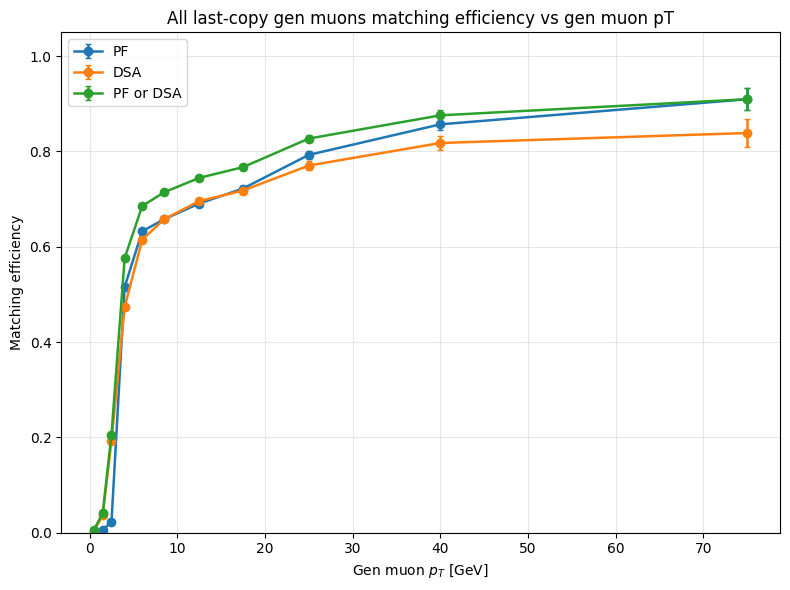

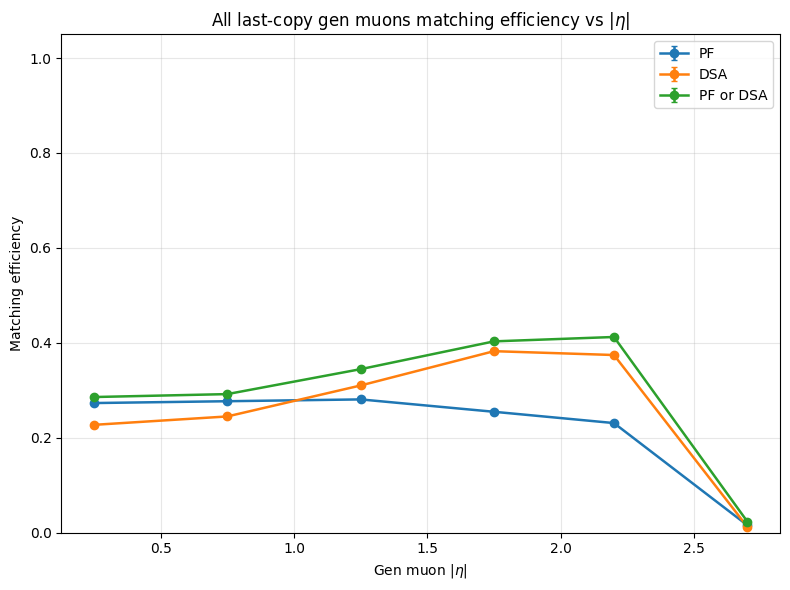

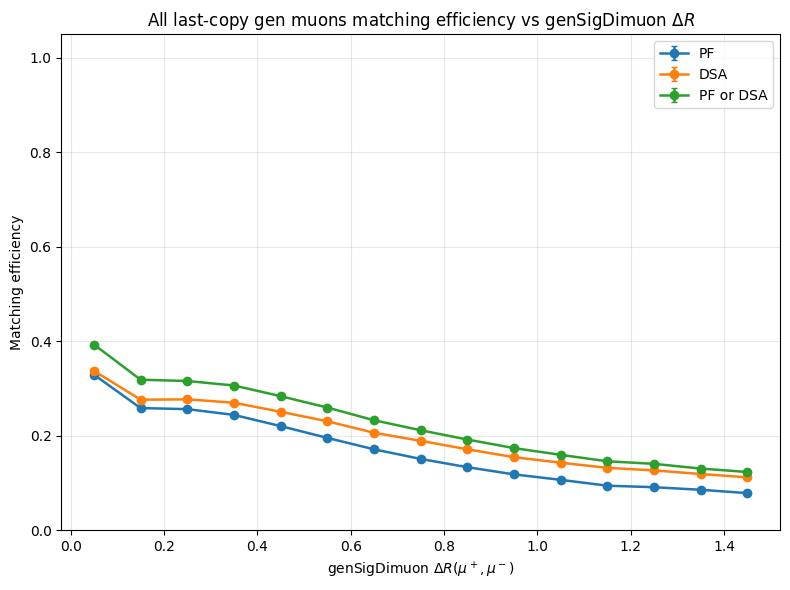

In [4]:
# Derived variables
df_match["abs_gen_eta"] = df_match["gen_eta"].abs()

# Binning
BINS = {
    "gen_pt": np.array([0, 1, 2, 3, 5, 7, 10, 15, 20, 30, 50, 100]),
    "abs_gen_eta": np.array([0.0, 0.5, 1.0, 1.5, 2.0, 2.4, 3.0]),
    "gen_eta": np.linspace(-3.0, 3.0, 13),
    "genSigDimuon_dr": np.linspace(0.0, 1.5, 16),
}


def binomial_error(eff, n):
    if n <= 0:
        return 0.0
    return np.sqrt(eff * (1.0 - eff) / n)


def make_efficiency_vs_variable(
    df,
    variable,
    bins,
    collection="GenParticleLastCopy",
    sample=None,
):
    d = df[df["gen_collection"] == collection].copy()

    if sample is not None:
        d = d[d["sample"] == sample].copy()

    d = d[np.isfinite(d[variable])].copy()

    d["var_bin"] = pd.cut(
        d[variable],
        bins=bins,
        right=False,
        include_lowest=True,
    )

    rows = []

    for varbin, g in d.groupby("var_bin", observed=True):
        if pd.isna(varbin):
            continue

        n = len(g)

        rows.append(
            {
                "collection": collection,
                "sample": sample if sample is not None else "all",
                "variable": variable,
                "bin": str(varbin),
                "bin_low": varbin.left,
                "bin_high": varbin.right,
                "bin_center": 0.5 * (varbin.left + varbin.right),
                "n_gen": n,

                "eff_PF": g["matched_PF"].mean(),
                "eff_DSA": g["matched_DSA"].mean(),
                "eff_either": g["matched_either"].mean(),

                "n_PF": int(g["matched_PF"].sum()),
                "n_DSA": int(g["matched_DSA"].sum()),
                "n_either": int(g["matched_either"].sum()),
            }
        )

    return pd.DataFrame(rows)


def plot_efficiency_three_reco_types(
    df_eff_var,
    xlabel,
    title,
    outname,
    ymin=0.0,
    ymax=1.05,
):
    plt.figure(figsize=(8, 6))

    for reco, eff_col in [
        ("PF", "eff_PF"),
        ("DSA", "eff_DSA"),
        ("PF or DSA", "eff_either"),
    ]:
        d = df_eff_var.sort_values("bin_center")

        x = d["bin_center"].values
        y = d[eff_col].values
        n = d["n_gen"].values

        yerr = np.array([binomial_error(yi, ni) for yi, ni in zip(y, n)])

        plt.errorbar(
            x,
            y,
            yerr=yerr,
            marker="o",
            linestyle="-",
            linewidth=1.8,
            capsize=2,
            label=reco,
        )

    plt.xlabel(xlabel)
    plt.ylabel("Matching efficiency")
    plt.ylim(ymin, ymax)
    plt.grid(True, alpha=0.3)
    plt.title(title)
    plt.legend()
    plt.tight_layout()

    plt.savefig(os.path.join(OUTDIR, outname + ".png"), dpi=150)
    plt.savefig(os.path.join(OUTDIR, outname + ".pdf"))

    plt.show()


# Make plots for all last-copy gen muons
collection = "GenParticleLastCopy"

df_eff_pt = make_efficiency_vs_variable(
    df_match,
    variable="gen_pt",
    bins=BINS["gen_pt"],
    collection=collection,
)

plot_efficiency_three_reco_types(
    df_eff_pt,
    xlabel=r"Gen muon $p_T$ [GeV]",
    title="All last-copy gen muons matching efficiency vs gen muon pT",
    outname="eff_GenParticleLastCopy_vs_genPt",
)

df_eff_abseta = make_efficiency_vs_variable(
    df_match,
    variable="abs_gen_eta",
    bins=BINS["abs_gen_eta"],
    collection=collection,
)

plot_efficiency_three_reco_types(
    df_eff_abseta,
    xlabel=r"Gen muon $|\eta|$",
    title=r"All last-copy gen muons matching efficiency vs $|\eta|$",
    outname="eff_GenParticleLastCopy_vs_absEta",
)

df_eff_dimuon_dr = make_efficiency_vs_variable(
    df_match,
    variable="genSigDimuon_dr",
    bins=BINS["genSigDimuon_dr"],
    collection=collection,
)

plot_efficiency_three_reco_types(
    df_eff_dimuon_dr,
    xlabel=r"genSigDimuon $\Delta R(\mu^+,\mu^-)$",
    title=r"All last-copy gen muons matching efficiency vs genSigDimuon $\Delta R$",
    outname="eff_GenParticleLastCopy_vs_genSigDimuonDR",
)

In [3]:
chain_test = make_chain(sample_to_files[samples[0]], tree_name=TREE_NAME)

print("DSA-related branches:")
for b in chain_test.GetListOfBranches():
    name = b.GetName()
    if "DSA" in name or "dsa" in name:
        print(name)

DSA-related branches:
nDSAMuon
recoDSAMuonPt
recoDSAMuonPtErr
recoDSAMuonEta
recoDSAMuonEtaErr
recoDSAMuonPhi
recoDSAMuonPhiErr
recoDSAMuonOuterEta
recoDSAMuonOuterPhi
recoDSAMuonE
recoDSAMuonPx
recoDSAMuonPy
recoDSAMuonPz
recoDSAMuonVxy
recoDSAMuonVz
recoDSAMuonDxy
recoDSAMuonDxyError
recoDSAMuonDz
recoDSAMuonDzError
recoDSAMuonTrkChi2
recoDSAMuonTrkProb
recoDSAMuonTrkNumTrackerHits
recoDSAMuonTrkNumPixHits
recoDSAMuonTrkNumStripHits
recoDSAMuonCharge
recoDSAMuonDisplacedId
recoDSAMuonTrkNumCSCHits
recoDSAMuonTrkNumHits
recoDSAMuonTrkNumPlanes
recoDSAMuonTrkNumDTHits
recoDSAMuonIdx
GenSigMuon_minDrToDSAMuon
GenSigMuon_matchDSAMuonIdx
GenSigAntiMuon_minDrToDSAMuon
GenSigAntiMuon_matchDSAMuonIdx


In [4]:
DSA_ID_BRANCH_CANDIDATES = [
    "recoDSAMuonDisplacedId"
]


def has_branch(chain, name):
    return bool(chain.GetBranch(name))


def first_existing_branch(chain, candidates, required=False):
    for name in candidates:
        if has_branch(chain, name):
            return name

    if required:
        print("Missing required branch. Tried:")
        for name in candidates:
            print("  ", name)
        raise RuntimeError("Required branch not found")

    return None


def detect_branches_with_dsa_id(chain):
    br = {}

    br["run"] = first_existing_branch(chain, ["runNum", "run"])
    br["lumi"] = first_existing_branch(chain, ["lumiSec", "lumi"])
    br["event"] = first_existing_branch(chain, ["eventNum", "event"])

    br["GenSigDimuon_isValid"] = first_existing_branch(
        chain,
        ["GenSigDimuon_isValid", "genSigDimuon_isValid"],
        required=True,
    )

    br["genSigDimuon_dr"] = first_existing_branch(
        chain,
        ["genSigDimuon_dr", "GenSigDimuon_dr"],
        required=True,
    )

    for obj in ["GenSigMuon", "GenSigAntiMuon"]:
        br[f"{obj}_isValid"] = first_existing_branch(chain, [f"{obj}_isValid"], required=True)
        br[f"{obj}_charge"] = first_existing_branch(chain, [f"{obj}_charge"], required=True)
        br[f"{obj}_pt"] = first_existing_branch(chain, [f"{obj}_pt"], required=True)
        br[f"{obj}_eta"] = first_existing_branch(chain, [f"{obj}_eta"], required=True)
        br[f"{obj}_phi"] = first_existing_branch(chain, [f"{obj}_phi"], required=True)
        br[f"{obj}_minDrToRecoMuon"] = first_existing_branch(chain, [f"{obj}_minDrToRecoMuon"], required=True)
        br[f"{obj}_minDrToDSAMuon"] = first_existing_branch(chain, [f"{obj}_minDrToDSAMuon"], required=True)

    br["nGenParticle"] = first_existing_branch(chain, ["nGenParticle"], required=True)
    br["GenParticle_ID"] = first_existing_branch(chain, ["GenParticle_ID", "genPartID"], required=True)
    br["GenParticle_status"] = first_existing_branch(chain, ["GenParticle_status", "genPartStatus"], required=True)
    br["GenParticle_isLastCopy"] = first_existing_branch(chain, ["GenParticle_isLastCopy", "genPartIsLastCopy"], required=True)
    br["GenParticle_firstDifferentMotherID"] = first_existing_branch(
        chain,
        ["GenParticle_firstDifferentMotherID", "genPartFirstDifferentMotherID"],
        required=True,
    )
    br["GenParticle_charge"] = first_existing_branch(chain, ["GenParticle_charge", "genPartCharge"], required=True)
    br["GenParticle_pt"] = first_existing_branch(chain, ["GenParticle_pt", "genPartPt"], required=True)
    br["GenParticle_eta"] = first_existing_branch(chain, ["GenParticle_eta", "genPartEta"], required=True)
    br["GenParticle_phi"] = first_existing_branch(chain, ["GenParticle_phi", "genPartPhi"], required=True)

    br["recoMuonPt"] = first_existing_branch(
        chain,
        ["recoMuonPt", "recoMuonPt_", "RecoMuonPt", "Muon_pt", "MuonPt"],
        required=True,
    )
    br["recoMuonEta"] = first_existing_branch(
        chain,
        ["recoMuonEta", "recoMuonEta_", "RecoMuonEta", "Muon_eta", "MuonEta"],
        required=True,
    )
    br["recoMuonPhi"] = first_existing_branch(
        chain,
        ["recoMuonPhi", "recoMuonPhi_", "RecoMuonPhi", "Muon_phi", "MuonPhi"],
        required=True,
    )
    br["recoMuonCharge"] = first_existing_branch(
        chain,
        ["recoMuonCharge", "recoMuonCharge_", "RecoMuonCharge", "Muon_charge", "MuonCharge"],
        required=True,
    )

    br["recoDSAMuonPt"] = first_existing_branch(
        chain,
        ["recoDSAMuonPt", "recoDSAMuonPt_", "RecoDSAMuonPt", "DSAMuon_pt", "DSAMuonPt"],
        required=True,
    )
    br["recoDSAMuonEta"] = first_existing_branch(
        chain,
        ["recoDSAMuonEta", "recoDSAMuonEta_", "RecoDSAMuonEta", "DSAMuon_eta", "DSAMuonEta"],
        required=True,
    )
    br["recoDSAMuonPhi"] = first_existing_branch(
        chain,
        ["recoDSAMuonPhi", "recoDSAMuonPhi_", "RecoDSAMuonPhi", "DSAMuon_phi", "DSAMuonPhi"],
        required=True,
    )
    br["recoDSAMuonCharge"] = first_existing_branch(
        chain,
        ["recoDSAMuonCharge", "recoDSAMuonCharge_", "RecoDSAMuonCharge", "DSAMuon_charge", "DSAMuonCharge"],
        required=True,
    )

    br["recoDSAMuonPassID"] = first_existing_branch(
        chain,
        DSA_ID_BRANCH_CANDIDATES,
        required=True,
    )

    return br

In [5]:
def scalar_bool(x):
    try:
        return bool(int(x))
    except Exception:
        return bool(x)


def scalar_float(x, default=-999.0):
    try:
        return float(x)
    except Exception:
        return default


def scalar_int(x, default=-999):
    try:
        return int(x)
    except Exception:
        return default


def vec_size(v):
    if v is None:
        return 0
    if hasattr(v, "size"):
        return int(v.size())
    return len(v)


def get_scalar(chain, branch_name, default=-999):
    if branch_name is None:
        return default
    try:
        return getattr(chain, branch_name)
    except Exception:
        return default


def get_vector(chain, branch_name):
    if branch_name is None:
        return None
    try:
        return getattr(chain, branch_name)
    except Exception:
        return None


def pdgid_to_charge(pid):
    pid = int(pid)
    if pid == 13:
        return -1
    if pid == -13:
        return +1
    return 0


ROOT.gInterpreter.Declare("""
#include "DataFormats/Math/interface/deltaR.h"

float deltaR_eta_phi_wrapper(float eta1, float phi1, float eta2, float phi2) {
    return reco::deltaR(eta1, phi1, eta2, phi2);
}
""")


def root_delta_r(eta1, phi1, eta2, phi2):
    return float(ROOT.deltaR_eta_phi_wrapper(float(eta1), float(phi1), float(eta2), float(phi2)))


def closest_same_sign_reco_root_delta_r(
    gen_eta,
    gen_phi,
    gen_charge,
    reco_etas,
    reco_phis,
    reco_charges,
    reco_pass_id=None,
    require_pass_id=False,
    dr_max=0.3,
):
    best_dr = 999.0
    best_idx = -1

    n_reco = vec_size(reco_etas)

    for i in range(n_reco):
        if require_pass_id:
            if reco_pass_id is None:
                continue
            if not bool(int(reco_pass_id[i])):
                continue

        reco_charge = int(reco_charges[i])

        if reco_charge != int(gen_charge):
            continue

        dr = root_delta_r(
            gen_eta,
            gen_phi,
            float(reco_etas[i]),
            float(reco_phis[i]),
        )

        if dr < best_dr:
            best_dr = dr
            best_idx = i

    matched = int(best_idx >= 0 and best_dr < dr_max)

    return {
        "matched": matched,
        "min_dr": best_dr,
        "idx": best_idx,
    }


def either_min_dr(min_dr_pf, min_dr_dsa):
    vals = []
    if min_dr_pf >= 0.0 and min_dr_pf < 900.0:
        vals.append(min_dr_pf)
    if min_dr_dsa >= 0.0 and min_dr_dsa < 900.0:
        vals.append(min_dr_dsa)
    return min(vals) if vals else 999.0

In [6]:
def add_genparticle_lastcopy_muon_rows_manual_dsa_id(rows, chain, br, sample, entry):
    if not scalar_bool(get_scalar(chain, br["GenSigDimuon_isValid"])):
        return

    dimuon_dr = scalar_float(get_scalar(chain, br["genSigDimuon_dr"]))

    reco_pf_eta = get_vector(chain, br["recoMuonEta"])
    reco_pf_phi = get_vector(chain, br["recoMuonPhi"])
    reco_pf_charge = get_vector(chain, br["recoMuonCharge"])

    reco_dsa_eta = get_vector(chain, br["recoDSAMuonEta"])
    reco_dsa_phi = get_vector(chain, br["recoDSAMuonPhi"])
    reco_dsa_charge = get_vector(chain, br["recoDSAMuonCharge"])
    reco_dsa_pass_id = get_vector(chain, br["recoDSAMuonPassID"])

    n_gen = scalar_int(get_scalar(chain, br["nGenParticle"]))

    gen_id = get_vector(chain, br["GenParticle_ID"])
    gen_status = get_vector(chain, br["GenParticle_status"])
    gen_is_last_copy = get_vector(chain, br["GenParticle_isLastCopy"])
    gen_first_diff_mother = get_vector(chain, br["GenParticle_firstDifferentMotherID"])
    gen_charge = get_vector(chain, br["GenParticle_charge"])
    gen_pt = get_vector(chain, br["GenParticle_pt"])
    gen_eta = get_vector(chain, br["GenParticle_eta"])
    gen_phi = get_vector(chain, br["GenParticle_phi"])

    for i in range(n_gen):
        pid = int(gen_id[i])

        if abs(pid) != 13:
            continue

        if int(gen_status[i]) != 1:
            continue

        if not bool(int(gen_is_last_copy[i])):
            continue

        q = int(gen_charge[i])

        if q == 0:
            q = pdgid_to_charge(pid)

        eta = float(gen_eta[i])
        phi = float(gen_phi[i])

        match_pf = closest_same_sign_reco_root_delta_r(
            eta,
            phi,
            q,
            reco_pf_eta,
            reco_pf_phi,
            reco_pf_charge,
            reco_pass_id=None,
            require_pass_id=False,
            dr_max=MATCH_DR_MAX,
        )

        match_dsa = closest_same_sign_reco_root_delta_r(
            eta,
            phi,
            q,
            reco_dsa_eta,
            reco_dsa_phi,
            reco_dsa_charge,
            reco_pass_id=reco_dsa_pass_id,
            require_pass_id=True,
            dr_max=MATCH_DR_MAX,
        )

        min_dr_pf = match_pf["min_dr"]
        min_dr_dsa = match_dsa["min_dr"]

        rows.append(
            {
                "sample": sample,
                "entry": entry,
                "gen_collection": "GenParticleLastCopy",
                "gen_object": "GenParticleMuon" if pid == 13 else "GenParticleAntiMuon",
                "gen_idx": i,
                "gen_pdgId": pid,
                "gen_charge": q,
                "gen_pt": float(gen_pt[i]),
                "gen_eta": eta,
                "gen_phi": phi,
                "gen_firstDifferentMotherID": int(gen_first_diff_mother[i]),
                "genSigDimuon_dr": dimuon_dr,

                "minDr_PF": min_dr_pf,
                "minDr_DSA": min_dr_dsa,
                "minDr_either": either_min_dr(min_dr_pf, min_dr_dsa),

                "matched_PF": int(match_pf["matched"]),
                "matched_DSA": int(match_dsa["matched"]),
                "matched_either": int(match_pf["matched"] or match_dsa["matched"]),

                "matchIdx_PF": match_pf["idx"],
                "matchIdx_DSA": match_dsa["idx"],

                "matching_source": "manual_ROOT_reco_deltaR_same_sign_DSA_ID",
            }
        )

In [7]:
CACHE_DIR = "matching_efficiency_cache"
os.makedirs(CACHE_DIR, exist_ok=True)

sample_cache_dir = os.path.join(CACHE_DIR, "per_sample_pkl_dsa_id")
os.makedirs(sample_cache_dir, exist_ok=True)

all_sample_dfs = []

for sample in samples:
    safe_sample = re.sub(r"[^a-zA-Z0-9_]+", "_", sample)
    sample_cache_path = os.path.join(sample_cache_dir, f"{safe_sample}.pkl")

    if os.path.exists(sample_cache_path):
        print(f"Loading cached {sample}")
        df_sample = pd.read_pickle(sample_cache_path)
        all_sample_dfs.append(df_sample)
        continue

    rows_sample = []

    chain = make_chain(sample_to_files[sample], tree_name=TREE_NAME)
    br = detect_branches_with_dsa_id(chain)

    chain.SetBranchStatus("*", 0)
    for b in br.values():
        if b is not None:
            chain.SetBranchStatus(b, 1)

    n_entries = chain.GetEntries()

    print(f"Processing {sample:35s}  events = {n_entries}")

    for entry in range(n_entries):
        chain.GetEntry(entry)

        add_genparticle_lastcopy_muon_rows_manual_dsa_id(
            rows_sample,
            chain,
            br,
            sample,
            entry,
        )

        if entry % 5000 == 0 and entry > 0:
            print(f"  processed {entry}/{n_entries}")

    df_sample = pd.DataFrame(rows_sample)

    df_sample.to_pickle(sample_cache_path)
    print(f"Saved cached sample: {sample_cache_path}")

    all_sample_dfs.append(df_sample)

df_match = pd.concat(all_sample_dfs, ignore_index=True)

df_match.to_pickle(os.path.join(CACHE_DIR, "df_match_dsa_id.pkl"))

print()
print(f"Rows = {len(df_match)}")
df_match.head()

Processing Mchi-5p25_dMchi-0p5_ctau-1           events = 30000
  processed 5000/30000
  processed 10000/30000
  processed 15000/30000
  processed 20000/30000
  processed 25000/30000
Saved cached sample: matching_efficiency_cache/per_sample_pkl_dsa_id/Mchi_5p25_dMchi_0p5_ctau_1.pkl
Processing Mchi-5p25_dMchi-0p5_ctau-10          events = 30000
  processed 5000/30000
  processed 10000/30000
  processed 15000/30000
  processed 20000/30000
  processed 25000/30000
Saved cached sample: matching_efficiency_cache/per_sample_pkl_dsa_id/Mchi_5p25_dMchi_0p5_ctau_10.pkl
Processing Mchi-5p25_dMchi-0p5_ctau-100         events = 30000
  processed 5000/30000
  processed 10000/30000
  processed 15000/30000
  processed 20000/30000
  processed 25000/30000
Saved cached sample: matching_efficiency_cache/per_sample_pkl_dsa_id/Mchi_5p25_dMchi_0p5_ctau_100.pkl
Processing Mchi-5p25_dMchi-0p5_ctau-1000        events = 15000
  processed 5000/15000
  processed 10000/15000
Saved cached sample: matching_efficiency_

,sample,entry,gen_collection,gen_object,gen_idx,gen_pdgId,gen_charge,gen_pt,gen_eta,gen_phi,...,genSigDimuon_dr,minDr_PF,minDr_DSA,minDr_either,matched_PF,matched_DSA,matched_either,matchIdx_PF,matchIdx_DSA,matching_source
0,Mchi-5p25_dMchi-0p5_ctau-1,0,GenParticleLastCopy,GenParticleAntiMuon,12,-13,1,5.697460,1.374590,-0.311607,...,0.016743,0.036649,0.026816,0.026816,1,1,1,0,0,manual_ROOT_reco_deltaR_same_sign_DSA_ID
1,Mchi-5p25_dMchi-0p5_ctau-1,0,GenParticleLastCopy,GenParticleMuon,13,13,-1,7.068364,1.387755,-0.301262,...,0.016743,0.040863,0.164089,0.040863,1,1,1,1,1,manual_ROOT_reco_deltaR_same_sign_DSA_ID
2,Mchi-5p25_dMchi-0p5_ctau-1,1,GenParticleLastCopy,GenParticleAntiMuon,11,-13,1,2.546337,-0.973851,-2.422798,...,0.072950,999.000000,999.000000,999.000000,0,0,0,-1,-1,manual_ROOT_reco_deltaR_same_sign_DSA_ID
3,Mchi-5p25_dMchi-0p5_ctau-1,1,GenParticleLastCopy,GenParticleMuon,12,13,-1,4.618337,-0.904399,-2.445116,...,0.072950,0.008318,0.110690,0.008318,1,1,1,0,0,manual_ROOT_reco_deltaR_same_sign_DSA_ID
4,Mchi-5p25_dMchi-0p5_ctau-1,2,GenParticleLastCopy,GenParticleAntiMuon,11,-13,1,2.062396,0.894620,0.300410,...,0.083919,2.508867,2.466866,2.466866,0,0,0,1,0,manual_ROOT_reco_deltaR_same_sign_DSA_ID


/cvmfs/cms.cern.ch/el8_amd64_gcc11/external/py3-numpy/1.22.4-aec0a210f14617f175dad913e0d72013/lib/python3.9/site-packages/numpy/core/getlimits.py:499: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/cvmfs/cms.cern.ch/el8_amd64_gcc11/external/py3-numpy/1.22.4-aec0a210f14617f175dad913e0d72013/lib/python3.9/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  return self._float_to_str(self.smallest_subnormal)


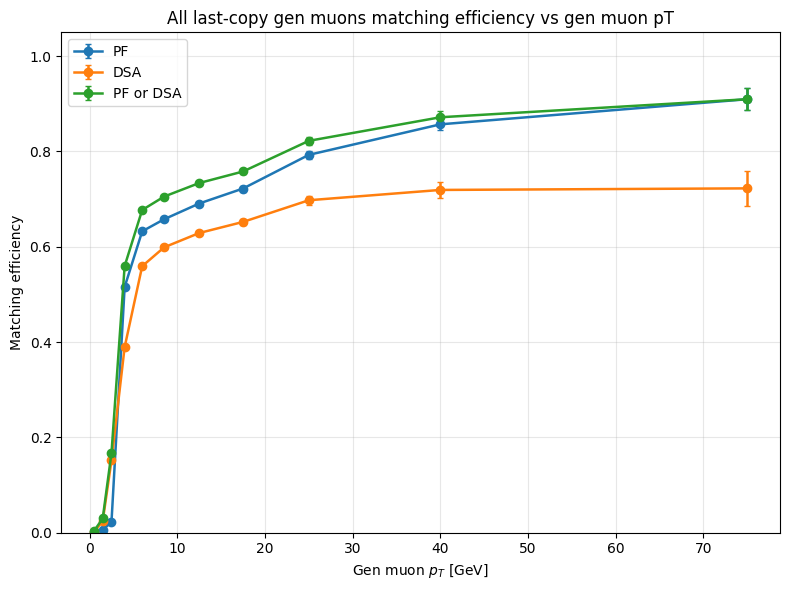

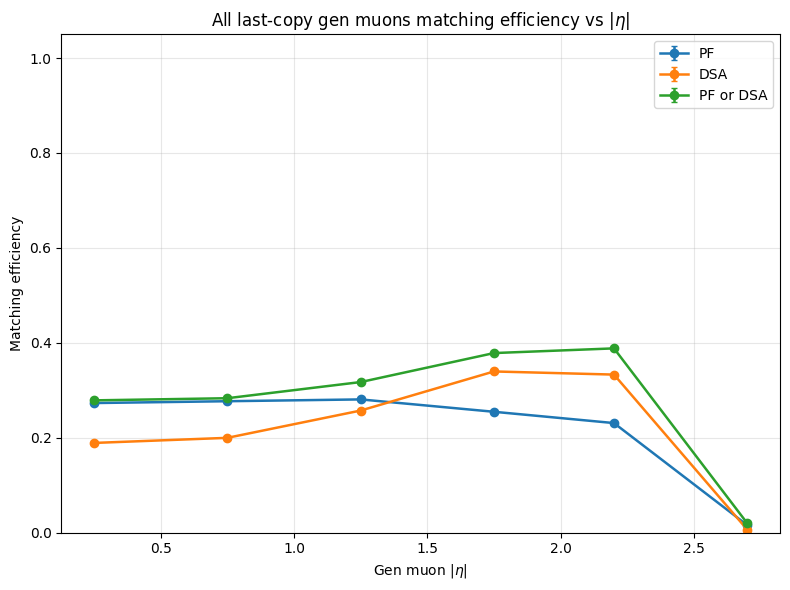

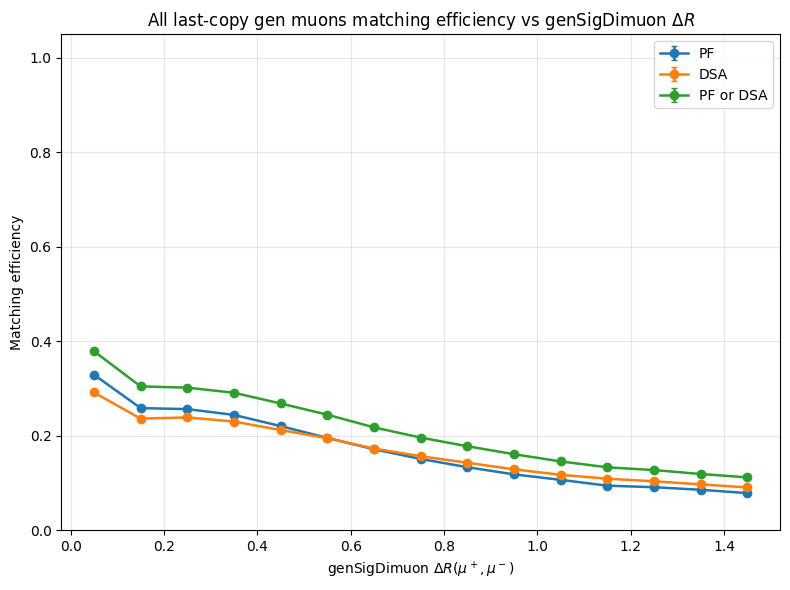

In [8]:
# Derived variables
df_match["abs_gen_eta"] = df_match["gen_eta"].abs()

# Binning
BINS = {
    "gen_pt": np.array([0, 1, 2, 3, 5, 7, 10, 15, 20, 30, 50, 100]),
    "abs_gen_eta": np.array([0.0, 0.5, 1.0, 1.5, 2.0, 2.4, 3.0]),
    "gen_eta": np.linspace(-3.0, 3.0, 13),
    "genSigDimuon_dr": np.linspace(0.0, 1.5, 16),
}


def binomial_error(eff, n):
    if n <= 0:
        return 0.0
    return np.sqrt(eff * (1.0 - eff) / n)


def make_efficiency_vs_variable(
    df,
    variable,
    bins,
    collection="GenParticleLastCopy",
    sample=None,
):
    d = df[df["gen_collection"] == collection].copy()

    if sample is not None:
        d = d[d["sample"] == sample].copy()

    d = d[np.isfinite(d[variable])].copy()

    d["var_bin"] = pd.cut(
        d[variable],
        bins=bins,
        right=False,
        include_lowest=True,
    )

    rows = []

    for varbin, g in d.groupby("var_bin", observed=True):
        if pd.isna(varbin):
            continue

        n = len(g)

        rows.append(
            {
                "collection": collection,
                "sample": sample if sample is not None else "all",
                "variable": variable,
                "bin": str(varbin),
                "bin_low": varbin.left,
                "bin_high": varbin.right,
                "bin_center": 0.5 * (varbin.left + varbin.right),
                "n_gen": n,

                "eff_PF": g["matched_PF"].mean(),
                "eff_DSA": g["matched_DSA"].mean(),
                "eff_either": g["matched_either"].mean(),

                "n_PF": int(g["matched_PF"].sum()),
                "n_DSA": int(g["matched_DSA"].sum()),
                "n_either": int(g["matched_either"].sum()),
            }
        )

    return pd.DataFrame(rows)


def plot_efficiency_three_reco_types(
    df_eff_var,
    xlabel,
    title,
    outname,
    ymin=0.0,
    ymax=1.05,
):
    plt.figure(figsize=(8, 6))

    for reco, eff_col in [
        ("PF", "eff_PF"),
        ("DSA", "eff_DSA"),
        ("PF or DSA", "eff_either"),
    ]:
        d = df_eff_var.sort_values("bin_center")

        x = d["bin_center"].values
        y = d[eff_col].values
        n = d["n_gen"].values

        yerr = np.array([binomial_error(yi, ni) for yi, ni in zip(y, n)])

        plt.errorbar(
            x,
            y,
            yerr=yerr,
            marker="o",
            linestyle="-",
            linewidth=1.8,
            capsize=2,
            label=reco,
        )

    plt.xlabel(xlabel)
    plt.ylabel("Matching efficiency")
    plt.ylim(ymin, ymax)
    plt.grid(True, alpha=0.3)
    plt.title(title)
    plt.legend()
    plt.tight_layout()

    plt.savefig(os.path.join(OUTDIR, outname + ".png"), dpi=150)
    plt.savefig(os.path.join(OUTDIR, outname + ".pdf"))

    plt.show()


# Make plots for all last-copy gen muons
collection = "GenParticleLastCopy"

df_eff_pt = make_efficiency_vs_variable(
    df_match,
    variable="gen_pt",
    bins=BINS["gen_pt"],
    collection=collection,
)

plot_efficiency_three_reco_types(
    df_eff_pt,
    xlabel=r"Gen muon $p_T$ [GeV]",
    title="All last-copy gen muons matching efficiency vs gen muon pT",
    outname="eff_GenParticleLastCopy_vs_genPt",
)

df_eff_abseta = make_efficiency_vs_variable(
    df_match,
    variable="abs_gen_eta",
    bins=BINS["abs_gen_eta"],
    collection=collection,
)

plot_efficiency_three_reco_types(
    df_eff_abseta,
    xlabel=r"Gen muon $|\eta|$",
    title=r"All last-copy gen muons matching efficiency vs $|\eta|$",
    outname="eff_GenParticleLastCopy_vs_absEta",
)

df_eff_dimuon_dr = make_efficiency_vs_variable(
    df_match,
    variable="genSigDimuon_dr",
    bins=BINS["genSigDimuon_dr"],
    collection=collection,
)

plot_efficiency_three_reco_types(
    df_eff_dimuon_dr,
    xlabel=r"genSigDimuon $\Delta R(\mu^+,\mu^-)$",
    title=r"All last-copy gen muons matching efficiency vs genSigDimuon $\Delta R$",
    outname="eff_GenParticleLastCopy_vs_genSigDimuonDR",
)